In [2]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from copy import deepcopy


from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# Original: df = pd.read_csv('data.csv')
# The file 'data.csv' was not found.
# Creating a dummy DataFrame for demonstration purposes.
data = {
    'feature1': np.random.rand(100),
    'feature2': np.random.rand(100) * 10,
    'target': np.random.rand(100) * 100
}
df = pd.DataFrame(data)

df.head()

,feature1,feature2,target
0,0.914591,0.601513,2.522709
1,0.676623,8.357400,96.613652
2,0.048065,4.062860,69.460024
3,0.147063,8.501324,42.640245
4,0.696712,7.294283,64.695642


In [3]:
df.head(10)

,feature1,feature2,target
0,0.914591,0.601513,2.522709
1,0.676623,8.357400,96.613652
2,0.048065,4.062860,69.460024
3,0.147063,8.501324,42.640245
4,0.696712,7.294283,64.695642
5,0.316273,8.223726,85.140025
6,0.901673,5.011475,28.172182
7,0.815304,8.625577,41.390765
8,0.482377,5.967746,18.231258
9,0.264809,1.510561,58.652778


### Preparing `df` for the provided code

The code you provided expects columns named `'Open'`, `'Close'`, `'High'`, and `'Low'` in the DataFrame `df`. Since the current `df` was generated as a dummy with different column names, I will create a new dummy DataFrame `df_stock` that matches the column requirements of your code. This ensures your code can execute without a `KeyError`.

In [5]:
np.random.seed(42)
data_stock = {
    'Open': np.random.rand(100) * 100,
    'High': np.random.rand(100) * 100 + 5,
    'Low': np.random.rand(100) * 100 - 5,
    'Close': np.random.rand(100) * 100,
    'Volume': np.random.randint(1000, 10000, 100)
}
df_stock = pd.DataFrame(data_stock)

df_stock.head()

,Open,High,Low,Close,Volume
0,37.454012,8.142919,59.203165,5.168172,5968
1,95.071431,68.641041,3.413996,53.135463,6917
2,73.199394,36.435598,11.162871,54.063512,9787
3,59.865848,55.857069,84.855419,63.742990,1728
4,15.601864,95.756647,55.642906,72.609133,2365


In [6]:
def return_pairs(column, days):
    pricess = list(column)
    X = []
    y = []
    for i in range(len(pricess) - days):
        X.append(pricess[i:i+days])
        y.append(pricess[i+days])
    return np.array(X), np.array(y)

target_columns =  ['Open', 'Close', 'High', 'Low']
day_chunks =  [30, 45, 60, 90, 120, 150 ,200, 250]

chunked_data = {}

# Using df_stock instead of df to match the expected columns
for col in target_columns:
    for days in day_chunks:
        # Ensure 'days' is not greater than the length of the column for return_pairs
        if days < len(df_stock[col]):
            key_X = f"X_{col}_{days}"
            key_y = f"y_{col}_{days}"
            X, y = return_pairs(df_stock[col], days)
            chunked_data[key_X] = X
            chunked_data[key_y] = y
        else:
            print(f"Skipping {col} for days={days} as it exceeds DataFrame length")


chunk_pairs = []

for key in chunked_data.keys():
    if key.startswith("X_"):
        y_key = key.replace("X_", "y_")
        if y_key in chunked_data:
            chunk_pairs.append([key, y_key])

print("Chunked Data Keys:")
for key in chunked_data.keys():
    print(key)

print("\nFirst 5 Chunk Pairs:")
for pair in chunk_pairs[:5]:
    print(pair)

Skipping Open for days=120 as it exceeds DataFrame length
Skipping Open for days=150 as it exceeds DataFrame length
Skipping Open for days=200 as it exceeds DataFrame length
Skipping Open for days=250 as it exceeds DataFrame length
Skipping Close for days=120 as it exceeds DataFrame length
Skipping Close for days=150 as it exceeds DataFrame length
Skipping Close for days=200 as it exceeds DataFrame length
Skipping Close for days=250 as it exceeds DataFrame length
Skipping High for days=120 as it exceeds DataFrame length
Skipping High for days=150 as it exceeds DataFrame length
Skipping High for days=200 as it exceeds DataFrame length
Skipping High for days=250 as it exceeds DataFrame length
Skipping Low for days=120 as it exceeds DataFrame length
Skipping Low for days=150 as it exceeds DataFrame length
Skipping Low for days=200 as it exceeds DataFrame length
Skipping Low for days=250 as it exceeds DataFrame length
Chunked Data Keys:
X_Open_30
y_Open_30
X_Open_45
y_Open_45
X_Open_60
y_O

In [9]:
chunked_data['X_Open_30'].shape

(70, 30)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional


def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=input_shape),
        Dense(1)   # regression output
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(50, activation='tanh'), input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [11]:
ml_models = [
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("RandomForest", RandomForestRegressor()),
    ("GradientBoosting", GradientBoostingRegressor()),
    ("SVR", SVR()),
    ("KNN", KNeighborsRegressor()),
    ("XGBoost", XGBRegressor(verbosity=0)),
    ("LightGBM", LGBMRegressor(verbosity=0))
]

dl_models = {
    "RNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "Bidirectional_LSTM": build_bilstm
}

In [12]:
trained_models = {}

for X, y in tqdm(chunk_pairs):
    X_data = chunked_data[X]
    y_data = chunked_data[y]

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.1, random_state=42
    )

    # ML models
    for model_name, model in tqdm(ml_models):
        key = model_name + '_' + X[2:]
        model_copy = deepcopy(model)
        model_copy.fit(X_train, y_train)

        y_train_pred = model_copy.predict(X_train)
        y_test_pred = model_copy.predict(X_test)

        trained_models[key] = {
            'model': model_copy,
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred))
        }

    # DL models
    X_train_rnn = np.expand_dims(X_train, -1)
    X_test_rnn = np.expand_dims(X_test, -1)

    for model_name, builder in tqdm(dl_models.items()):
        key = model_name + '_' + X[2:]
        model_dl = builder((X_train.shape[1], 1))

        model_dl.fit(X_train_rnn, y_train, epochs=10, batch_size=8, verbose=0)

        y_train_pred = model_dl.predict(X_train_rnn).flatten()
        y_test_pred = model_dl.predict(X_test_rnn).flatten()

        trained_models[key] = {
            'model': model_dl,
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred))
        }


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

  0%|          | 0/4 [00:00<?, ?it/s]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


  0%|          | 0/9 [00:00<?, ?it/s]

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there ar

  0%|          | 0/4 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


In [13]:
results_df = pd.DataFrame([
    {"Model": name, **metrics}
    for name, metrics in trained_models.items()])

results_df.sort_values(by = 'test_mae', ascending = True).head(50)

,Model,model,train_mae,train_rmse,test_mae,test_rmse
96,SVR_Close_90,SVR(),2.144351e+01,2.587049e+01,0.278578,0.278578
50,GRU_Open_90,"<Sequential name=sequential_14, built=True>",4.768696e+01,5.320724e+01,0.555118,0.555118
49,LSTM_Open_90,"<Sequential name=sequential_13, built=True>",4.839493e+01,5.374973e+01,1.110228,1.110228
48,RNN_Open_90,"<Sequential name=sequential_12, built=True>",4.837175e+01,5.389389e+01,1.400353,1.400353
51,Bidirectional_LSTM_Open_90,"<Sequential name=sequential_15, built=True>",4.863974e+01,5.399729e+01,1.640072,1.640072
91,LinearRegression_Close_90,LinearRegression(),3.315866e-14,3.653906e-14,3.815317,3.815317
92,Ridge_Close_90,Ridge(),2.685162e-04,3.007538e-04,3.815617,3.815617
99,LightGBM_Close_90,LGBMRegressor(verbosity=0),2.338360e+01,2.456644e+01,9.919725,9.919725
186,GradientBoosting_Low_60,([DecisionTreeRegressor(criterion='friedman_ms...,7.507155e-03,8.940374e-03,12.062975,13.530534
185,RandomForest_Low_60,"(DecisionTreeRegressor(max_features=1.0, rando...",8.731401e+00,1.038364e+01,13.913249,18.102659


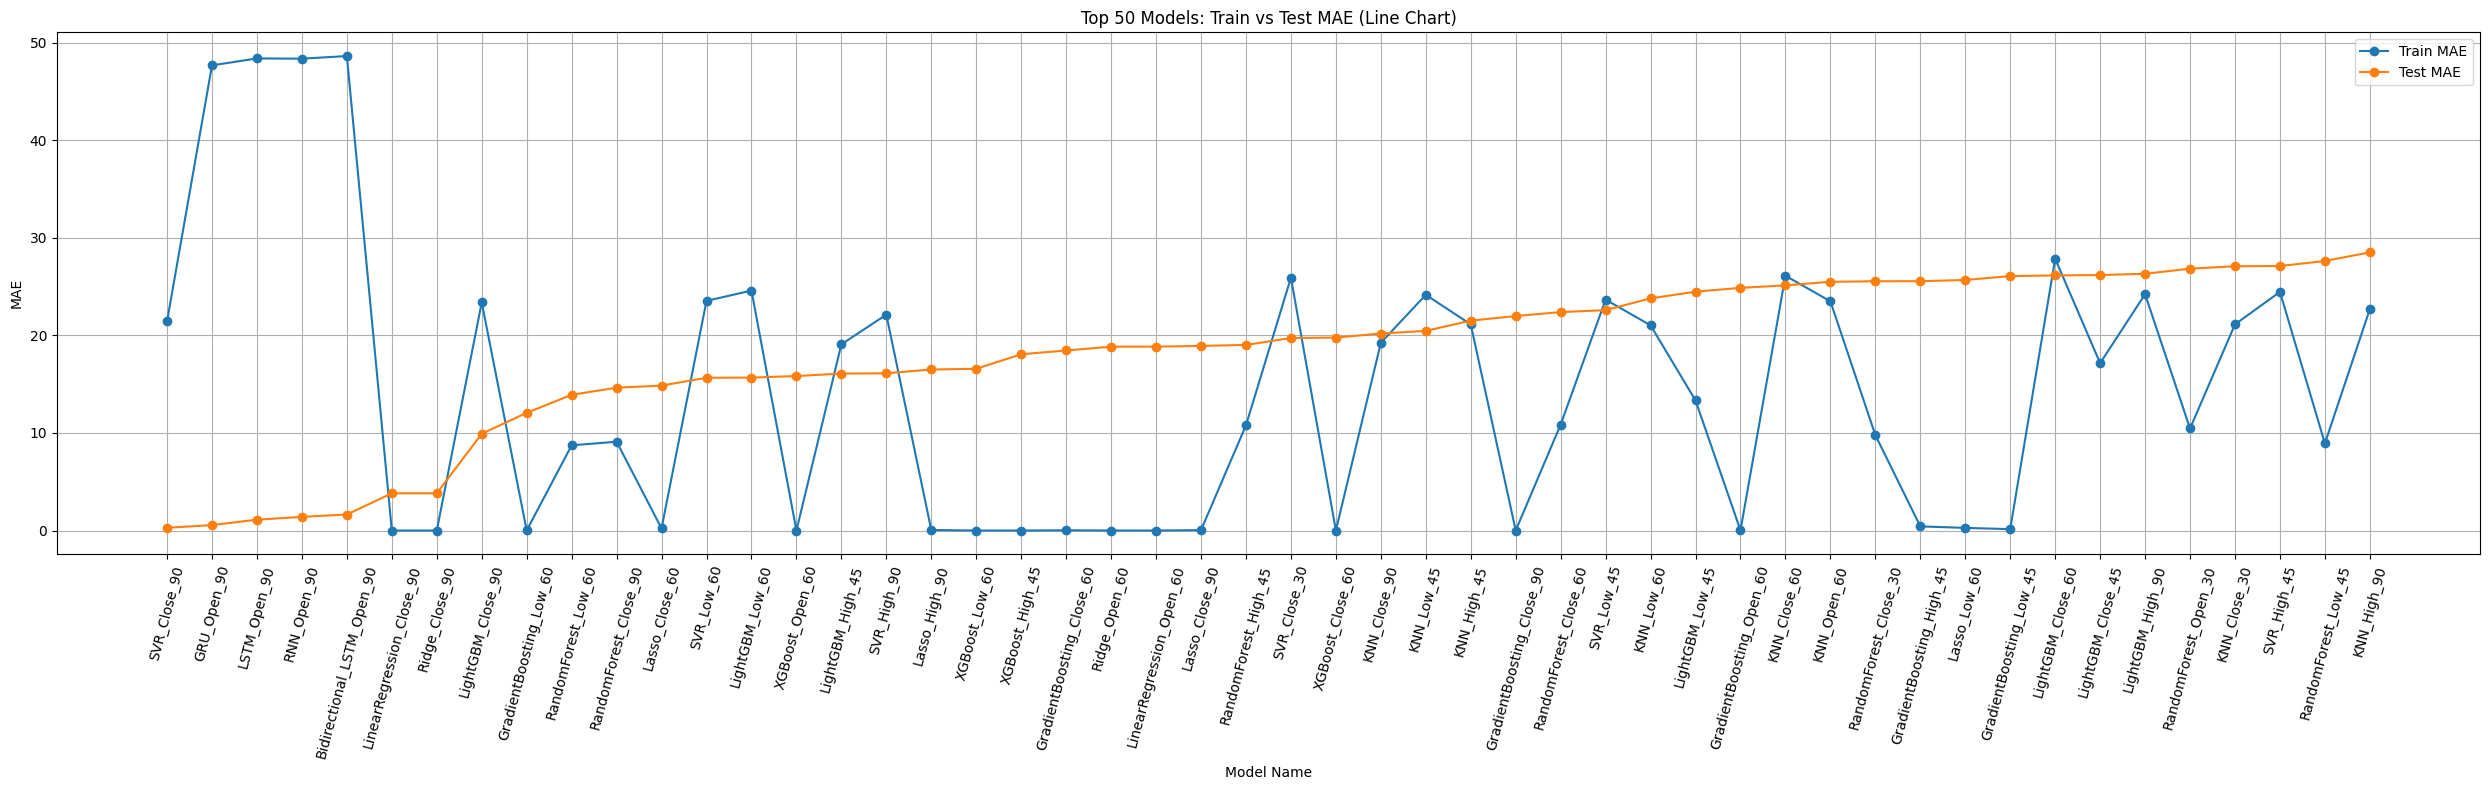

In [14]:
import matplotlib.pyplot as plt


top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)

plt.figure(figsize=(25, 8))
plt.plot(top_50['Model'], top_50['train_mae'], marker='o', label='Train MAE')

plt.plot(top_50['Model'], top_50['test_mae'], marker='o', label='Test MAE')

plt.xticks(rotation=75)
plt.xlabel('Model Name')
plt.ylabel('MAE')
plt.title('Top 50 Models: Train vs Test MAE (Line Chart)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

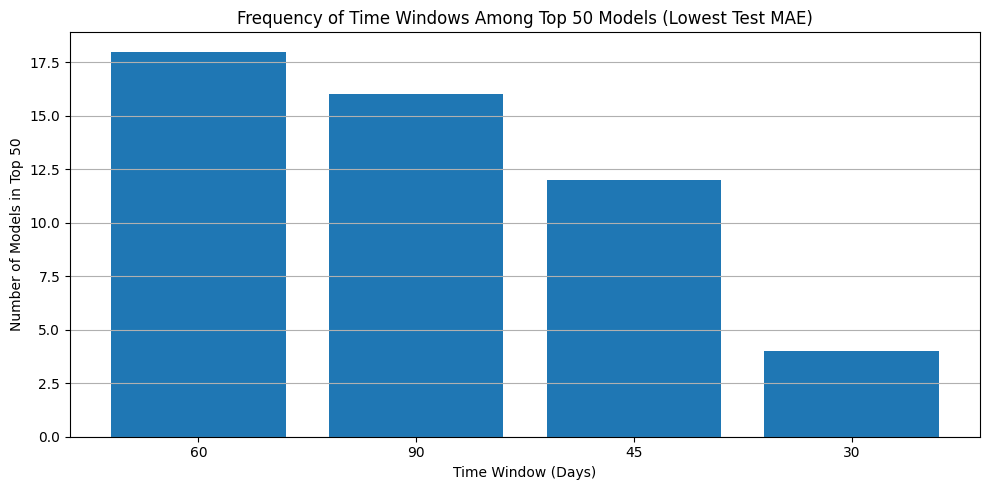

In [15]:
top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)
time_windows = pd.Series([i.split('_')[-1] for i in top_50['Model']])
time_counts = time_windows.value_counts().sort_values(ascending=False)  # Sort by count

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(time_counts.index, time_counts.values)

# Labels and aesthetics
plt.xlabel('Time Window (Days)')
plt.ylabel('Number of Models in Top 50')
plt.title('Frequency of Time Windows Among Top 50 Models (Lowest Test MAE)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

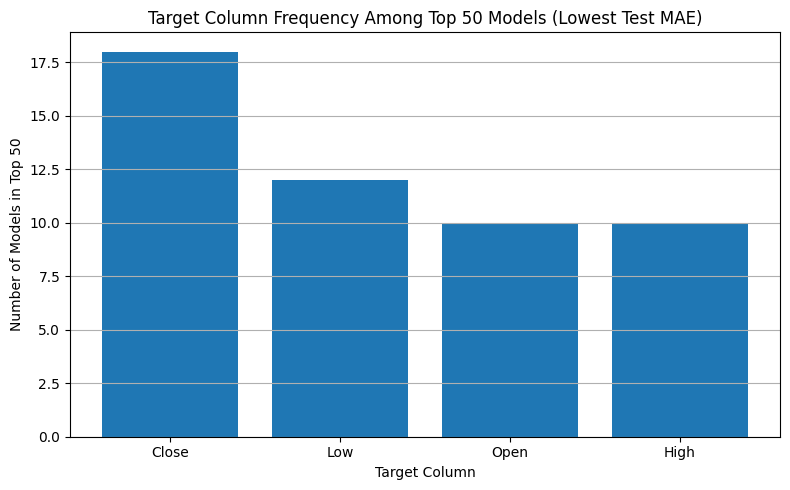

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract target columns from top 50 models
top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)
target_columns = pd.Series([i.split('_')[-2] for i in top_50['Model']])
target_counts = target_columns.value_counts().sort_values(ascending=False)  # Sort by count

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(target_counts.index, target_counts.values)

# Labels and aesthetics
plt.xlabel('Target Column')
plt.ylabel('Number of Models in Top 50')
plt.title('Target Column Frequency Among Top 50 Models (Lowest Test MAE)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


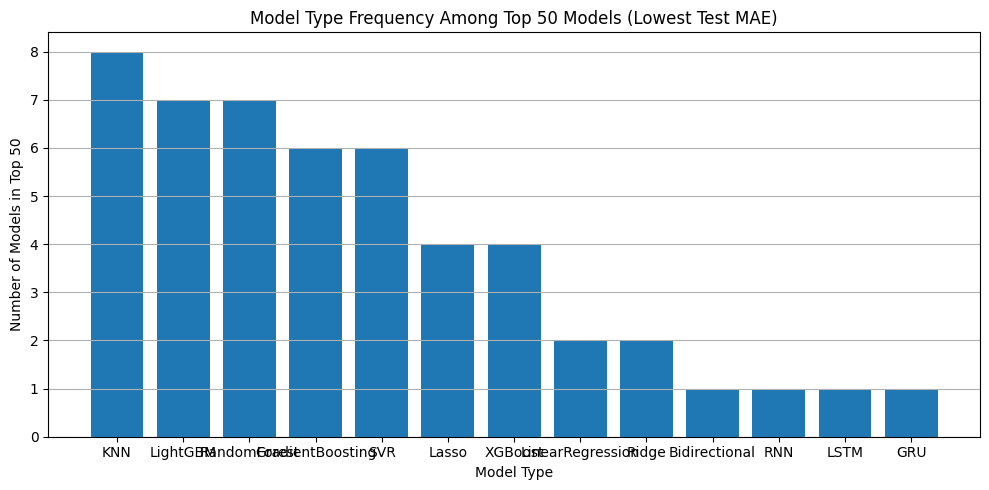

In [17]:
top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)
model_types = pd.Series([i.split('_')[0] for i in top_50['Model']])
model_counts = model_types.value_counts().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(model_counts.index, model_counts.values)

# Labels and aesthetics
plt.xlabel('Model Type')
plt.ylabel('Number of Models in Top 50')
plt.title('Model Type Frequency Among Top 50 Models (Lowest Test MAE)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [18]:
import joblib

results_df.to_csv('models.csv')
joblib.dump(trained_models, 'trained_models.joblib')

loaded_models = joblib.load('trained_models.joblib')

In [19]:
loaded_models['KNN_High_90']
model = loaded_models['KNN_High_90']['model']

In [20]:
print(chunked_data['X_Open_90'][5])
print(model.predict([chunked_data['X_Open_90'][5]]))

[15.59945203  5.80836122 86.61761458 60.11150117 70.80725778  2.05844943
 96.99098522 83.24426408 21.23391107 18.18249672 18.34045099 30.4242243
 52.47564316 43.19450186 29.12291402 61.18528947 13.94938607 29.21446485
 36.63618433 45.60699842 78.51759614 19.96737822 51.42344384 59.24145689
  4.64504127 60.75448519 17.05241237  6.5051593  94.88855373 96.56320331
 80.83973481 30.46137692  9.7672114  68.42330265 44.01524937 12.20382348
 49.51769101  3.43885211 90.93204021 25.87799816 66.25222844 31.17110761
 52.00680212 54.67102793 18.48544555 96.95846278 77.51328234 93.94989416
 89.48273504 59.78999788 92.1874235   8.84925021 19.59828624  4.52272889
 32.53303308 38.86772897 27.13490318 82.87375092 35.67533267 28.09345097
 54.26960832 14.0924225  80.21969808  7.45506437 98.68869366 77.22447693
 19.87156815  0.55221171 81.54614285 70.68573438 72.9007168  77.12703467
  7.40446517 35.84657285 11.58690595 86.31034259 62.32981268 33.08980249
  6.35583503 31.09823217 32.5183322  72.96061783 63.